# Open Data Day 2026 - Balneabilidade da Baixada 🏖

In [ ]:
# Por Marcos Zanetti - https://www.linkedin.com/in/marcos-zanetti/
import requests
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import json

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## Dados baixados de urls

In [ ]:

url = "https://arcgis.cetesb.sp.gov.br/server/rest/services/Hosted/classificacao_anual_balneabilidade_2005_2024/FeatureServer/0/query"
parametros_consulta = {
    "where": "1=1",
    "outFields": "ugrhi,municipio,praia,ano_2020,ano_2021,ano_2022,ano_2023,ano_2024",
    "returnGeometry": "true",
    "outSR": 4326, # long/lat para humanos
    "geometryType": "esriGeometryEnvelope",
    "f": "json"
}

try:
    response = requests.get(url, params=parametros_consulta)
    response.raise_for_status()
    balneabilidade_json = response.json()

except requests.exceptions.RequestException as e:
    print(f"Erro ao acessar a CETESB: {e}")

try:
    mapa_bairros = gpd.read_file(
    "https://egov.santos.sp.gov.br/geoserver/santos/ows?"
    "service=WFS&version=1.0.0&request=GetFeature&"
    "typeName=santos:bairros&outputFormat=application/json"
)
except Exception as e:
    print(f"Erro ao acessar os dados da Santos Mapeada: {e}")


## Dados do Drive para apresentação

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# balneabilidade_json = json.load("/content/drive/MyDrive/Py013/ODD_2026/cetesb_balneabilidade_anos.json")
# mapa_bairros = gpd.read_file("/content/drive/MyDrive/Py013/ODD_2026/geoserver-santos-bairros.application")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Processamentos

In [ ]:
lista_balneabilidade = []

for feature in balneabilidade_json.get('features', []):
    item = feature['attributes'].copy()

    geometria = feature.get('geometry', {})
    item['longitude'] = geometria.get('x')
    item['latitude'] = geometria.get('y')

    lista_balneabilidade.append(item)

# Mostrando só alguns exemplos
for registro in lista_balneabilidade[:3]:
    print(registro)

print(f"\nRegistros salvos: {len(lista_balneabilidade)}")

{'ugrhi': 'LITORAL NORTE', 'ano_2022': 'REGULAR', 'ano_2021': 'REGULAR', 'ano_2020': 'BOA', 'municipio': 'UBATUBA', 'ano_2024': 'REGULAR', 'ano_2023': 'RUIM', 'praia': 'PICINGUABA', 'longitude': -44.838033332688475, 'latitude': -23.378113889645483}
{'ugrhi': 'LITORAL NORTE', 'ano_2022': 'BOA', 'ano_2021': 'BOA', 'ano_2020': 'BOA', 'municipio': 'UBATUBA', 'ano_2024': 'REGULAR', 'ano_2023': 'RUIM', 'praia': 'LAGOA PRUMIRIM', 'longitude': -44.95578055632145, 'latitude': -23.378733333521524}
{'ugrhi': 'LITORAL NORTE', 'ano_2022': 'OTIMA', 'ano_2021': 'OTIMA', 'ano_2020': 'BOA', 'municipio': 'UBATUBA', 'ano_2024': 'OTIMA', 'ano_2023': 'OTIMA', 'praia': 'PRUMIRIM', 'longitude': -44.95747222194275, 'latitude': -23.379194444602884}

Registros salvos: 175


In [ ]:
df_balneabilidade = pd.DataFrame(lista_balneabilidade)
geometrias_pontos_praias = [Point(xy) for xy in zip(df_balneabilidade.longitude, df_balneabilidade.latitude)]
gdf_balneabilidade = gpd.GeoDataFrame(df_balneabilidade, geometry=geometrias_pontos_praias, crs="EPSG:4326")

#https://www.atribuna.com.br/cidades/santos/saiba-quais-s-o-os-10-bairros-com-aluguel-mais-caro-em-santos-no-litoral-de-s-o-paulo-1.438278
#Regex: ^.+? - (.+?) - Valor médio do m²: R\$(.+?) – Valor médio do aluguel: R\$(.+?)$
df_valores_aluguel = pd.DataFrame([
  {'bairro':'Pompéia','val_medio_m2':57.11,'val_medio_aluguel':5505.36},
  {'bairro':'Estuário','val_medio_m2':57.07,'val_medio_aluguel':5139.17},
  {'bairro':'Gonzaga','val_medio_m2':58.38,'val_medio_aluguel':4484.94},
  {'bairro':'José Menino','val_medio_m2':52.56,'val_medio_aluguel':4655.85},
  {'bairro':'Ponta da Praia','val_medio_m2':50.63,'val_medio_aluguel':4500.89},
  {'bairro':'Aparecida','val_medio_m2':50.87,'val_medio_aluguel':4361.93},
  {'bairro':'Embaré','val_medio_m2':57.25,'val_medio_aluguel':4252.29},
  {'bairro':'Boqueirão','val_medio_m2':47.66,'val_medio_aluguel':3957.84},
  {'bairro':'Vila Belmiro','val_medio_m2':47.52,'val_medio_aluguel':3771.49},
  {'bairro':'Marapé','val_medio_m2':50.63,'val_medio_aluguel':3695.38}
])

# Padronizando com nomes do Geoserver
mapa_bairros['nome'] = mapa_bairros['nome'].str.upper()
df_valores_aluguel['bairro'] = df_valores_aluguel['bairro'].str.upper()

# Join com polígonos da prefeitura
mapa_mergido_aluguel = mapa_bairros.merge(df_valores_aluguel, left_on='nome', right_on='bairro', how='left')

# Camada 1
m = mapa_mergido_aluguel.explore(
    column='val_medio_aluguel',
    cmap='Blues',
    tooltip=['nome', 'val_medio_aluguel'],
    name="Valor Aluguel Médio",
    tiles="CartoDB positron",
    nan_color="#dcdcdc"
)

# Camada 2
gdf_balneabilidade.explore(
    m=m,
    column='ano_2024',
    cmap='RdYlGn_r',
    categories=['OTIMA','BOA','REGULAR','RUIM','PESSIMA'],
    tooltip=['praia', 'ano_2024'],
    name="Balneabilidade 2024",
    marker_type='circle_marker',
    marker_kwds=dict(radius=6, fill=True, fillOpacity=1, color="black", weight=1)
)

display(m)

## Densidade Demográfica x Qualidade média

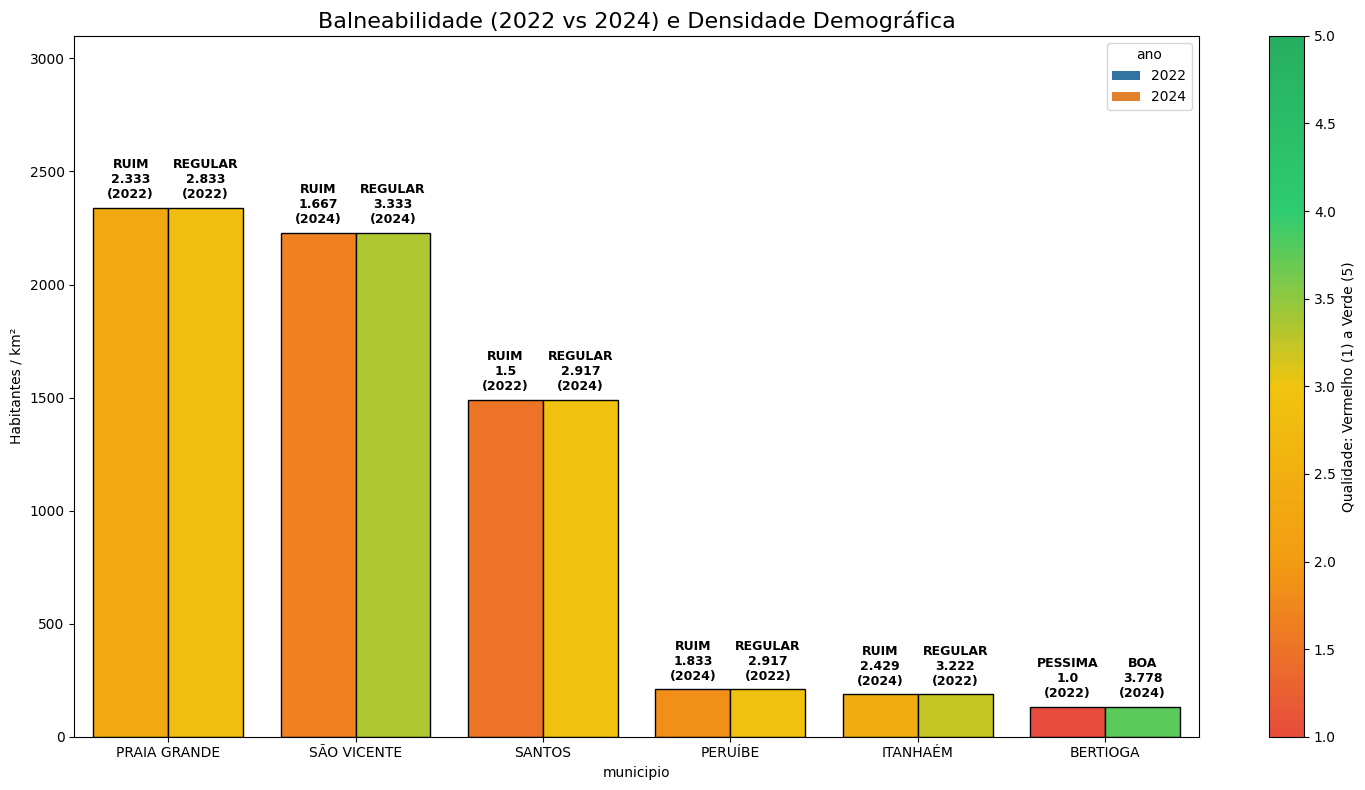

In [ ]:
# Dados de Densidade IBGE - ex https://www.ibge.gov.br/cidades-e-estados/sp/santos.html
censo_2022_hab_km2 = {
    'SANTOS': 1489.53,
    'SÃO VICENTE': 2226.86,
    'PRAIA GRANDE': 2338.32,
    'BERTIOGA': 130.58,
    'MONGUAGUÁ': 433.97,
    'ITANHAÉM': 186.93,
    'PERUÍBE': 209.53
}

mapa_pontos = {'PESSIMA': 1, 'RUIM': 2, 'REGULAR': 3, 'BOA': 4, 'OTIMA': 5}
inv_mapa = {v: k for k, v in mapa_pontos.items()}
cores_lista = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
my_cmap = mcolors.LinearSegmentedColormap.from_list("balne_cmap", cores_lista)
norm = plt.Normalize(1, 5)

df_balne = pd.DataFrame(lista_balneabilidade)
df_balne = df_balne[df_balne['municipio'].isin(censo_2022_hab_km2.keys())].copy()

for ano in ['ano_2022', 'ano_2024']:
    df_balne[f'{ano}_num'] = df_balne[ano].map(mapa_pontos)

df_resumo = df_balne.groupby('municipio')[['ano_2022_num', 'ano_2024_num']].mean().reset_index()
df_resumo['densidade'] = df_resumo['municipio'].map(censo_2022_hab_km2)

# Transformando para formato "Longo" (Tidying data)
df_long = pd.melt(df_resumo, id_vars=['municipio', 'densidade'],
                  value_vars=['ano_2022_num', 'ano_2024_num'],
                  var_name='ano', value_name='score_balne')

df_long['ano'] = df_long['ano'].str.replace('_num', '').str.replace('ano_', '')
df_long = df_long.sort_values('densidade', ascending=False)

plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=df_long,
    x='municipio',
    y='densidade',
    hue='ano',
)

#Seaborn cria as barras na ordem
for i in range(len(df_long)):
    bar= ax.patches[i]
    score = df_long.iloc[i]['score_balne']
    cor_balne = my_cmap(norm(score))
    bar.set_facecolor(cor_balne)
    bar.set_edgecolor('black')
    bar.set_linewidth(1)

    status_label = inv_mapa.get(round(score), "S/D")
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f"{status_label}\n{round(score,3)}\n({df_long.iloc[i]['ano']})",
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

plt.title('Balneabilidade (2022 vs 2024) e Densidade Demográfica', fontsize=16)
plt.ylabel('Habitantes / km²')
plt.ylim(0, 3100)

# Barra na direita
sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Qualidade: Vermelho (1) a Verde (5)')

plt.tight_layout()
plt.show()

# Quem é a CETESB?

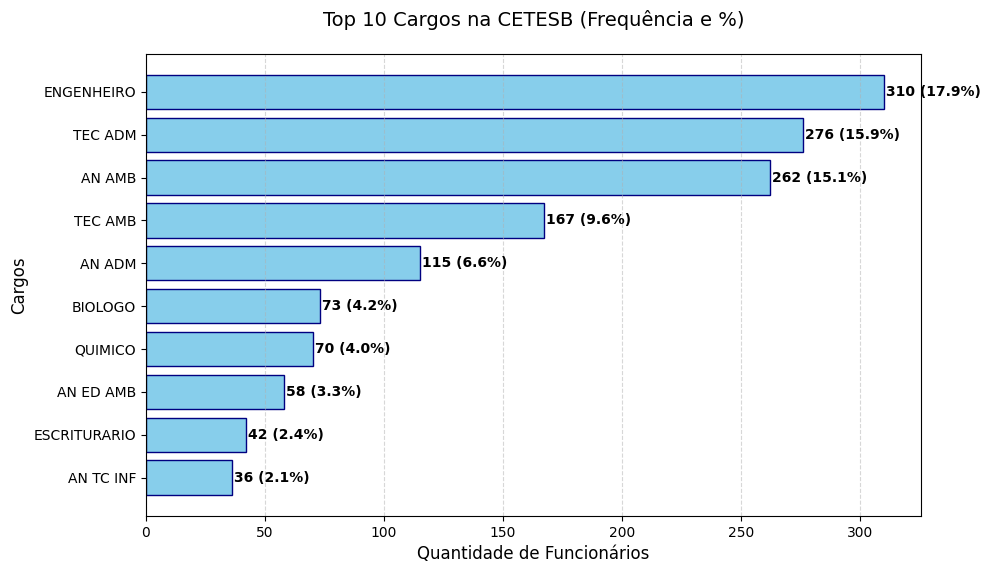

In [ ]:
# https://www.transparencia.sp.gov.br/home/Remuneracao
dados_cetesb = pd.read_csv('/content/drive/MyDrive/Py013/ODD_2026/cetesb_servidores_ativos_jan_2026.txt', sep='\t')
top_10 = dados_cetesb.iloc[:, 2].value_counts().head(10)

plt.figure(figsize=(10, 6))
barras = plt.barh(top_10.index, top_10.values, color='skyblue', edgecolor='navy')

for i, barra in enumerate(barras):
    quantidade = barra.get_width()
    porcentagem = (quantidade / len(dados_cetesb)) * 100
    plt.text(quantidade + 1, barra.get_y() + barra.get_height()/2,
             f'{int(quantidade)} ({porcentagem:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Cargos na CETESB (Frequência e %)', fontsize=14, pad=20)
plt.xlabel('Quantidade de Funcionários', fontsize=12)
plt.ylabel('Cargos', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()